In [1]:
%load_ext autoreload
%autoreload 2

import torch 
import os
#set project root
# Récupérer le répertoire du notebook actuel
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
# Remonter de deux niveaux dans l'arborescence pour atteindre la racine du projet
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
# Changer le répertoire de travail
os.chdir(project_root)
print(os.getcwd())
import numpy as np
import scipy as sp
from src import utils
from torch import nn
from torch import optim
import matplotlib.pyplot as plt
from src.net import TMA_net
from src.training.training import Trainer
from src.utils.misc import TrainerConfig
import torch.utils.data as data_utils
from sklearn.model_selection import train_test_split
from src.utils.misc import snv
from scipy.signal import savgol_filter
import pandas as pd
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.model_selection import train_test_split
#from pyarrow import set_timezone_db_path
from torch.backends.mkl import verbose

/home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics


In [2]:
 

mango_original = pd.read_csv(r"data/dataset/Mango/NAnderson2020MendeleyMangoNIRData.csv")
file = mango_original.copy()




In [3]:

 
# Colonnes stables pour définir une joue de mangue (échantillon)
replicate_cols = ['Set', 'Season', 'Region', 'Date', 'Type', 'Cultivar', 'Pop', 'DM']

 
# Regroupement pour définir les samples uniques
file['sample'] = file.groupby(replicate_cols).ngroup() + 1
file['sample'] = file['sample'].apply(lambda x: f'sample {x}')
 
# Placer 'sample' en 10e colonne
cols = list(file.columns)
cols.remove('sample')
cols.insert(9, 'sample')
file = file[cols]
 
# Chaque joue de mangue est mesurée 2 ou 6 fois, aucun échantillon ne devrait être seul.
# Extraire samples seuls
sample_counts = file['sample'].value_counts()
single_samples = sample_counts[sample_counts == 1].index.tolist()
df_single = file[file['sample'].isin(single_samples)][['sample', 'DM']]
 
# Trier par DM pour plus d'efficacité
df_single = df_single.sort_values('DM').reset_index(drop=True)
 
# Chercher paires avec DM proche
close_pairs = []
 
for i in range(len(df_single)):
    for j in range(i+1, len(df_single)):
        diff = abs(df_single.loc[i, 'DM'] - df_single.loc[j, 'DM'])
        if diff <= 0.0001:
            close_pairs.append((df_single.loc[i, 'sample'], df_single.loc[j, 'sample'], diff))
        else:
            # Comme le dataframe est trié, on peut break pour gagner du temps
            break
 
# Afficher les paires proches
for s1, s2, d in close_pairs:
    print(f"{s1} et {s2} ont un DM proche (diff = {d:.4f})")
 
# grouper les mangues seules
file['sample'] = file['sample'].replace({'sample 574': 'sample 575', 'sample 853': 'sample 854'})
print(file['sample'].nunique()) # on obtient 4675 échantillons (joues de mangues) dont ils parlent dans le papier
 
# Liste des spectres groupés par joue
duplicate_list = file.groupby(['sample']).apply(lambda x: list(x.index)).dropna().tolist()
 
# Split into training, validation and test sets
cal_val_indices, test_indices = train_test_split(duplicate_list, test_size=0.2, random_state=42)
cal_indices, val_indices = train_test_split(cal_val_indices, test_size=0.2, random_state=42)
 
# Flatten the lists
cal_indices = [item for sublist in cal_indices for item in sublist]
val_indices = [item for sublist in val_indices for item in sublist]
test_indices = [item for sublist in test_indices for item in sublist]
 
# save the sets
dataset_random_split = {
    "Xcal": file.iloc[cal_indices].drop(columns=["Set", "Season", "Region", "Date", "Type", "Cultivar", "Pop", "Temp", "DM", "sample"]).to_numpy(),
    "Xval": file.iloc[val_indices].drop(columns=["Set", "Season", "Region", "Date", "Type", "Cultivar", "Pop", "Temp", "DM", "sample"]).to_numpy(),
    "Xtest": file.iloc[test_indices].drop(columns=["Set", "Season", "Region", "Date", "Type", "Cultivar", "Pop", "Temp", "DM", "sample"]).to_numpy(),
    "Ycal": np.expand_dims(file.iloc[cal_indices]["DM"].to_numpy(), axis=1), # expand dims so the shape is (n,1) instead of (n,)
    "Yval": np.expand_dims(file.iloc[val_indices]["DM"].to_numpy(), axis=1),
    "Ytest": np.expand_dims(file.iloc[test_indices]["DM"].to_numpy(), axis=1),
}
 

sample 574 et sample 575 ont un DM proche (diff = 0.0000)
sample 853 et sample 854 ont un DM proche (diff = 0.0001)
4675


/tmp/ipykernel_22138/238792289.py:45: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  duplicate_list = file.groupby(['sample']).apply(lambda x: list(x.index)).dropna().tolist()


In [4]:
Ycal = dataset_random_split["Ycal"]
Yval = dataset_random_split["Yval"]
Ytest = dataset_random_split["Ytest"]
Xcal = dataset_random_split["Xcal"][:,50:-50]
Xval = dataset_random_split["Xval"][:,50:-50]
Xtest = dataset_random_split["Xtest"][:,50:-50]
print("X and Y training set")
print(Ycal.shape)
print(Xcal.shape)

print("X and Y val set")
print(Yval.shape)
print(Xval.shape)

print("X and Y testing set")
print(Ytest.shape)
print(Xtest.shape)

X and Y training set
(7443, 1)
(7443, 206)
X and Y val set
(1917, 1)
(1917, 206)
X and Y testing set
(2331, 1)
(2331, 206)


Text(0.5, 0.98, 'Histogram of Y sets')

<Figure size 1200x600 with 0 Axes>

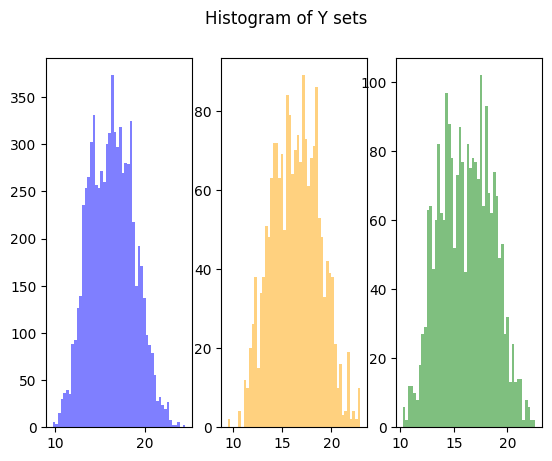

In [5]:
# plot histogram of each Y set
plt.figure(figsize=(12, 6))
fig, ax = plt.subplots(1, 3)
ax[0].hist(Ycal, bins=50, alpha=0.5, label='Ycal', color='blue')
ax[1].hist(Yval, bins=50, alpha=0.5, label='Yval', color='orange')
ax[2].hist(Ytest, bins=50, alpha=0.5, label='Ytest', color='green')
plt.suptitle('Histogram of Y sets')


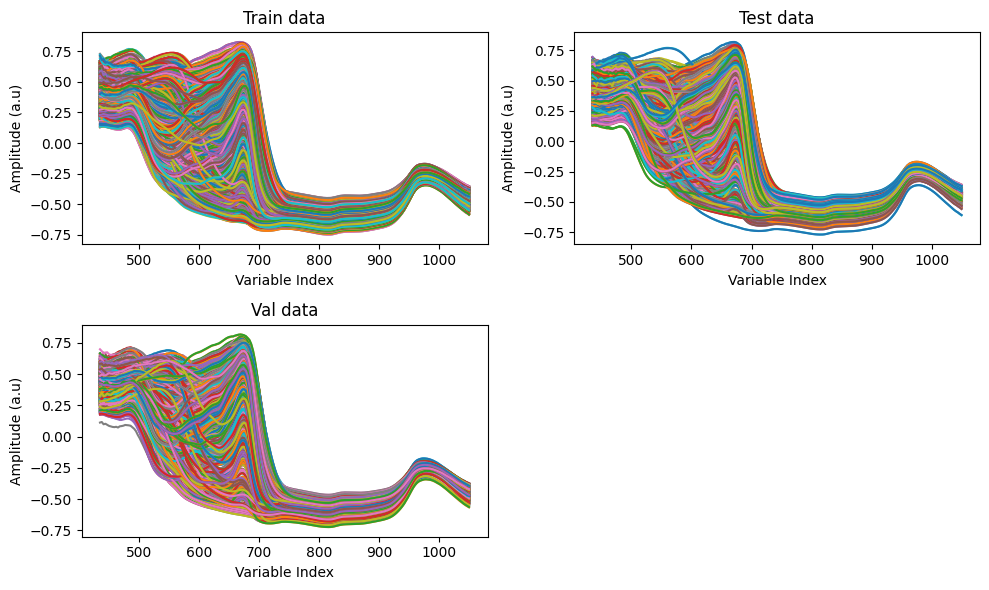

In [6]:
lmb = file.columns[-306:]
lmb = lmb.values.astype(int)[50:-50]
plt.figure(figsize=(10,6))
plt.subplot(221)
plt.title('Train data')
plt.plot(lmb,Xcal.T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(222)
plt.title('Test data')
plt.plot(lmb, Xtest.T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(223)
plt.title('Val data')
plt.plot(lmb, Xval.T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')

plt.tight_layout()
plt.show()

In [7]:
SG_Width = 13
SG_poly = 2

x_cal_snv = snv(Xcal)
x_val_snv = snv(Xval)
x_test_snv = snv(Xtest)

x_cal_SG1 = savgol_filter(Xcal, SG_Width, SG_poly, deriv = 1,axis=0)
x_val_SG1 = savgol_filter(Xval, SG_Width, SG_poly, deriv = 1,axis=0)
x_test_SG1 = savgol_filter(Xtest, SG_Width, SG_poly, deriv = 1,axis=0)


x_cal_SG2 = savgol_filter(Xcal, SG_Width, SG_poly, deriv = 2,axis=0)
x_val_SG2 = savgol_filter(Xval, SG_Width, SG_poly, deriv = 2,axis=0)
x_test_SG2= savgol_filter(Xtest, SG_Width, SG_poly, deriv = 2,axis=0)

x_cal_snv_SG1 = savgol_filter(x_cal_snv, SG_Width, SG_poly, deriv = 1,axis=0)
x_val_snv_SG1 = savgol_filter(x_val_snv, SG_Width, SG_poly, deriv = 1,axis=0)
x_test_snv_SG1 = savgol_filter(x_test_snv, SG_Width, SG_poly, deriv = 1,axis=0)


x_cal_snv_SG2 = savgol_filter(x_cal_snv, SG_Width, SG_poly, deriv = 2,axis=0)
x_val_snv_SG2 = savgol_filter(x_val_snv, SG_Width, SG_poly, deriv = 2,axis=0)
x_test_snv_SG2= savgol_filter(x_test_snv, SG_Width, SG_poly, deriv = 2,axis=0)

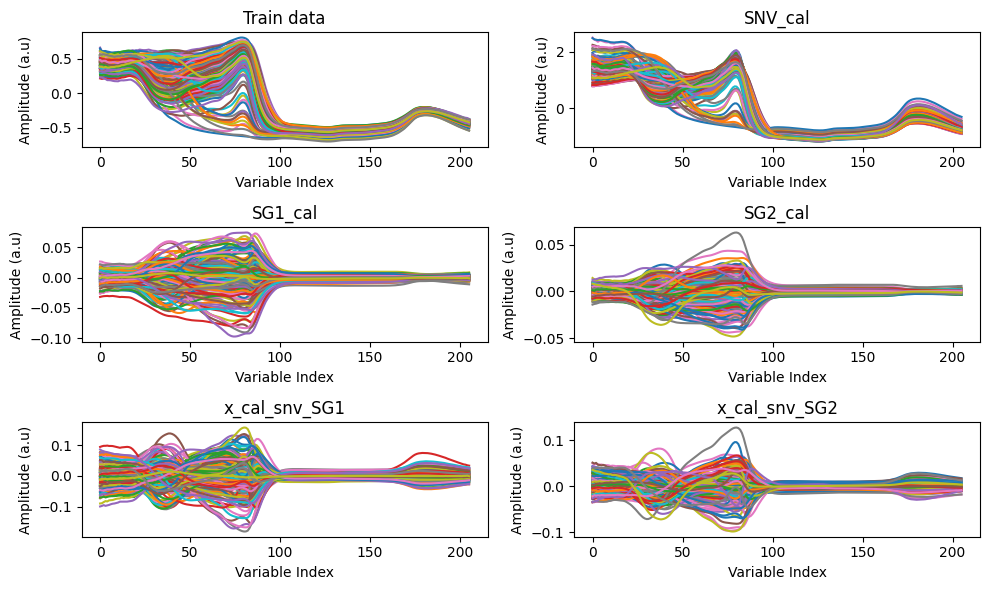

In [8]:
plt.figure(figsize=(10,6))
plt.subplot(321)
plt.title('Train data')
plt.plot(Xcal[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(322)
plt.title('SNV_cal')
plt.plot(x_cal_snv[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(323)
plt.title('SG1_cal')
plt.plot(x_cal_SG1[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(324)
plt.title('SG2_cal')
plt.plot(x_cal_SG2[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(325)
plt.title('x_cal_snv_SG1')
plt.plot(x_cal_snv_SG1[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.subplot(326)
plt.title('x_cal_snv_SG2')
plt.plot(x_cal_snv_SG2[::50,:].T)
plt.ylabel('Amplitude (a.u)')
plt.xlabel('Variable Index')
plt.tight_layout()
plt.show()



In [9]:
# Concatenate the preprocessed data
# unsqueeze the data to add a channel dimension
Xcal = np.expand_dims(Xcal, axis=2)
Xval = np.expand_dims(Xval, axis=2)
Xtest = np.expand_dims(Xtest, axis=2)

x_cal_snv = np.expand_dims(x_cal_snv, axis=2)
x_val_snv = np.expand_dims(x_val_snv, axis=2)
x_test_snv = np.expand_dims(x_test_snv, axis=2)

x_cal_SG1 = np.expand_dims(x_cal_SG1, axis=2)
x_val_SG1 = np.expand_dims(x_val_SG1, axis=2)
x_test_SG1 = np.expand_dims(x_test_SG1, axis=2)

x_cal_SG2 = np.expand_dims(x_cal_SG2, axis=2)
x_val_SG2 = np.expand_dims(x_val_SG2, axis=2)
x_test_SG2 = np.expand_dims(x_test_SG2, axis=2)

x_cal_snv_SG1 = np.expand_dims(x_cal_snv_SG1, axis=2)
x_val_snv_SG1 = np.expand_dims(x_val_snv_SG1, axis=2)
x_test_snv_SG1 = np.expand_dims(x_test_snv_SG1, axis=2)

x_cal_snv_SG2 = np.expand_dims(x_cal_snv_SG2, axis=2)
x_val_snv_SG2 = np.expand_dims(x_val_snv_SG2, axis=2)
x_test_snv_SG2 = np.expand_dims(x_test_snv_SG2, axis=2)
# Concatenate the data along the channel dimension
Xcal_concat = np.concatenate((Xcal, x_cal_snv, x_cal_SG1, x_cal_SG2, x_cal_snv_SG1, x_cal_snv_SG2), axis=2)
Xval_concat = np.concatenate((Xval, x_val_snv, x_val_SG1, x_val_SG2, x_val_snv_SG1, x_val_snv_SG2), axis=2)
Xtest_concat = np.concatenate((Xtest, x_test_snv, x_test_SG1, x_test_SG2, x_test_snv_SG1, x_test_snv_SG2), axis=2)
print("Xcal_concat shape:", Xcal_concat.shape)
print("Xval_concat shape:", Xval_concat.shape)
print("Xtest_concat shape:", Xtest_concat.shape) 


Xcal_concat shape: (7443, 206, 6)
Xval_concat shape: (1917, 206, 6)
Xtest_concat shape: (2331, 206, 6)


In [10]:
## Reshape according Torch training requirements
Xcal_concat = Xcal_concat.transpose(0, 2, 1)  # Transpose to (samples, channels, features)
Xval_concat = Xval_concat.transpose(0, 2, 1)  # Transpose to (samples, channels, features)
Xtest_concat = Xtest_concat.transpose(0, 2, 1)  # Transpose to (samples, channels, features)

## Check for dimensions
print('Data set dimensions ----------------------------')
print('Full Train set dims X Y = {}\t{}'.format(Xcal_concat.shape, Ycal.shape))
print('Test set dims X Y = {}\t{}'.format(Xtest_concat.shape, Ytest.shape))



Data set dimensions ----------------------------
Full Train set dims X Y = (7443, 6, 206)	(7443, 1)
Test set dims X Y = (2331, 6, 206)	(2331, 1)


In [11]:
# calculate mean and std per column

mean = np.mean(Xcal_concat, axis=0)
std = np.std(Xcal_concat, axis=0)
print("Mean shape:", mean.shape)
print("Std shape:", std.shape)


Mean shape: (6, 206)
Std shape: (6, 206)


In [12]:

model_name ="TMA_Mango"

spec_dims = Xcal_concat.shape[2]
print("Spectral dimensions:", spec_dims)

# create trainer config
config = TrainerConfig(model_name = model_name)
config.update_config(batch_size=1024,learning_rate=0.01,num_epochs=300,classification=False,max_loss_plot=20)
print(config)

x_cal_std = (Xcal_concat - mean) / std
x_val_std = (Xval_concat - mean) / std    
Xtest_concat_std = (Xtest_concat - mean) / std

Spectral dimensions: 206
TrainerConfig(batch_size=1024, learning_rate=0.01, num_epochs=300, device=cuda, save_model=True,  classification=False, max_loss_plot=20,save_path=/home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/TMA_Mango)


In [13]:


# Convert np.array to Dataloader 
# add dt in loader 

cal = data_utils.TensorDataset(torch.Tensor(x_cal_std), torch.Tensor(Ycal))
cal_loader = data_utils.DataLoader(cal, batch_size=config.batch_size, shuffle=True)

val = data_utils.TensorDataset(torch.Tensor(x_val_std), torch.Tensor(Yval))
val_loader = data_utils.DataLoader(val, batch_size=config.batch_size, shuffle=False)

test_dt = data_utils.TensorDataset(torch.Tensor(Xtest_concat_std), torch.Tensor(Ytest))
test_loader = data_utils.DataLoader(test_dt, batch_size=config.batch_size, shuffle=False)


In [14]:
# import DoE experiment

Doe_run = pd.read_csv("data/dataset/Mango/DoE_TMA_Net/Optimize_TMA_net_step1_new.csv",delimiter=';',decimal=",").to_dict(orient='records')


print(Doe_run[0])



{'Exp No': 1, 'Exp Name': 'N1', 'Run Order': 1, 'Incl/Excl': 'Incl', 'kernel_size': 5, 'aggregation_mode': 'avg', 'n_filters': 1, 'fc_dim1': 128, 'dropout': 0.1, 'MSE': nan, 'R2': nan}


In [19]:
# Run DoE experiment
results_table = []
for run in Doe_run:
    print(f"Running experiment: {run['Exp Name']}")    
    model_name = f"DOE_TMA_Mango_Dario_split_replicate_ok_{run['Exp Name']}"
    config = TrainerConfig(model_name = model_name)
    config.update_config(batch_size=1024,learning_rate=0.01,num_epochs=500,classification=False,max_loss_plot=20)

    model = TMA_net(
        input_dims=spec_dims,
        input_channel=x_cal_std.shape[1],
        kernel_size=run['kernel_size'],
        aggregation_mode=run['aggregation_mode'],
        n_filters=run['n_filters'],
        kernel_size_aggregation=1,
        fc1_dims=run['fc_dim1'],
        dropout=run['dropout'],
        out_dims=1
    )

    #print(model)

    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=0.003/2)
    criterion = nn.MSELoss(reduction='mean')
    trainer = Trainer(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_loader=cal_loader,
        val_loader=val_loader,
        config=config,
        verbose=False,
    )
    train_losses, val_losses,val_r2_scores, final_path = trainer.train()
    results_table.append({
    "Exp Name": run["Exp Name"],
    "Final Val MSE": val_losses[-1].item(),
    "Final Val R²": np.mean(val_r2_scores[-1])
    })
    print(f"Training completed for {model_name}. Final path: {final_path}")

Running experiment: N1
Training completed for DOE_TMA_Mango_Dario_split_replicate_ok_N1. Final path: /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/DOE_TMA_Mango_Dario_split_replicate_ok_N1_best.pth
Running experiment: N2
Training completed for DOE_TMA_Mango_Dario_split_replicate_ok_N2. Final path: /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/DOE_TMA_Mango_Dario_split_replicate_ok_N2_best.pth
Running experiment: N3
Training completed for DOE_TMA_Mango_Dario_split_replicate_ok_N3. Final path: /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/DOE_TMA_Mango_Dario_split_replicate_ok_N3_best.pth
Running experiment: N4
Training completed for DOE_TMA_Mango_Dario_split_replicate_ok_N4. Final path: /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/DOE_TMA_Mango_Dario_split_replicate_ok_N4_best.

In [20]:
df_results = pd.DataFrame(results_table)
print(df_results)

   Exp Name  Final Val MSE  Final Val R²
0        N1       0.638794      0.891737
1        N2       1.925565      0.673655
2        N3       1.214463      0.794173
3        N4       0.912069      0.845422
4        N5       0.716510      0.878566
5        N6       1.580842      0.732079
6        N7       5.903508     -0.000527
7        N8       0.774960      0.868660
8        N9       6.984696     -0.183767
9       N10       2.403020      0.592736
10      N11       4.808453      0.185063
11      N12       3.887644      0.341122
12      N13       1.959824      0.667849


In [21]:
df_results.to_csv("data/dataset/Mango/DoE_TMA_Net/DoE_results_MSE_R2_new.csv", index=False,sep=';', decimal=',')


TMA_net(
  (dropout): Dropout(p=0.1, inplace=False)
  (conv1d): Conv1d(6, 6, kernel_size=(5,), stride=(1,), padding=same, groups=6)
  (aggregate_block): channel_mean()
  (fc1): Linear(in_features=206, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (norm): LayerNorm((6, 206), eps=1e-05, elementwise_affine=True)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)
Saving best model to /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/DOE_TMA_Mango_Dario_split_replicate_ok_N13_best.pth
Epoch 1/1000 | Train Loss: 466.5239 | Val Loss: 122.2285 | Val Mean Metrics: -19.7153
Model saved at epoch 0 to /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/DOE_TMA_Mango_Dario_split_replicate_ok_N13_best.pth
Epoch 2/1000 | Train Loss: 77.7629 | Val Loss: 28.5207 | Val Mean Metrics: -3.

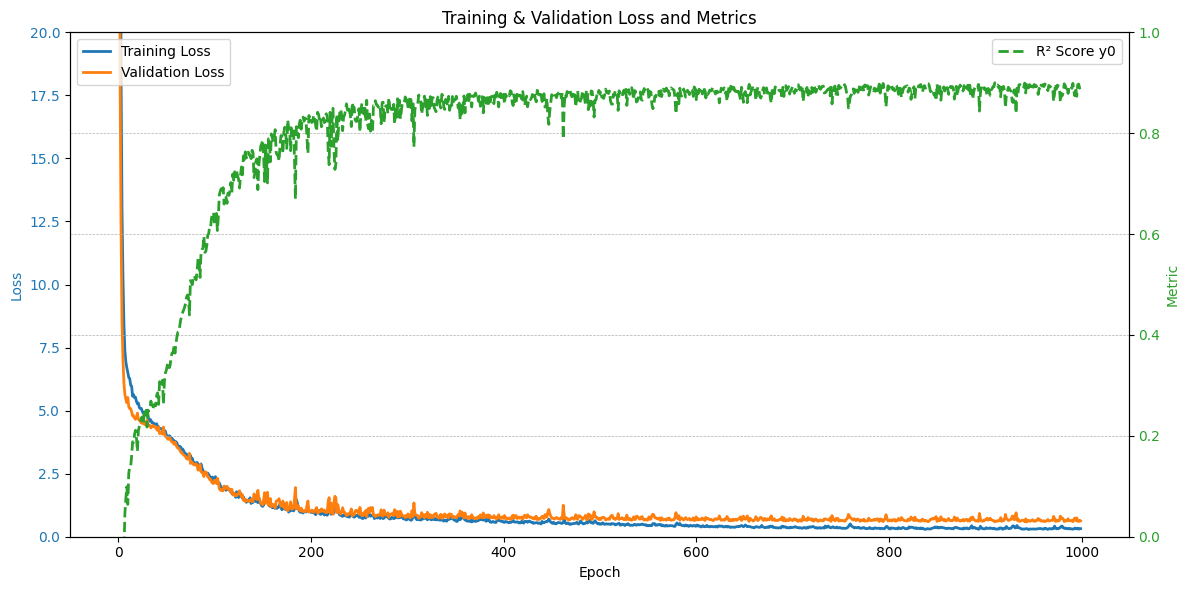

Training completed for TMA_net_opti. Final path: /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/DOE_TMA_Mango_Dario_split_replicate_ok_N13_best.pth


In [21]:

model_name = 'TMA_net_opti'
config.model_name = model_name
model = TMA_net(input_dims = spec_dims, input_channel = x_cal_std.shape[1], kernel_size = 5 ,aggregation_mode = "avg", n_filters = 1, kernel_size_aggregation = 3 ,fc1_dims = 128, dropout=0.1, out_dims=1)
config.num_epochs = 1000


optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=0.003/2)
criterion = nn.MSELoss(reduction='none')
print(model)

trainer = Trainer(model=model, optimizer=optimizer, criterion=criterion, train_loader=cal_loader, val_loader=val_loader, config=config,verbose=True)

train_losses, val_losses,val_r2_scores, final_path = trainer.train()
print(f"Training completed for {model_name}. Final path: {final_path}")




tensor([0.5837])
CCC: 0.9553346068102516, R2: 0.9112885594367981, RMSEP: 0.7223513722419739
Shape of Y: (2331,), Shape of y_pred: (2331,)


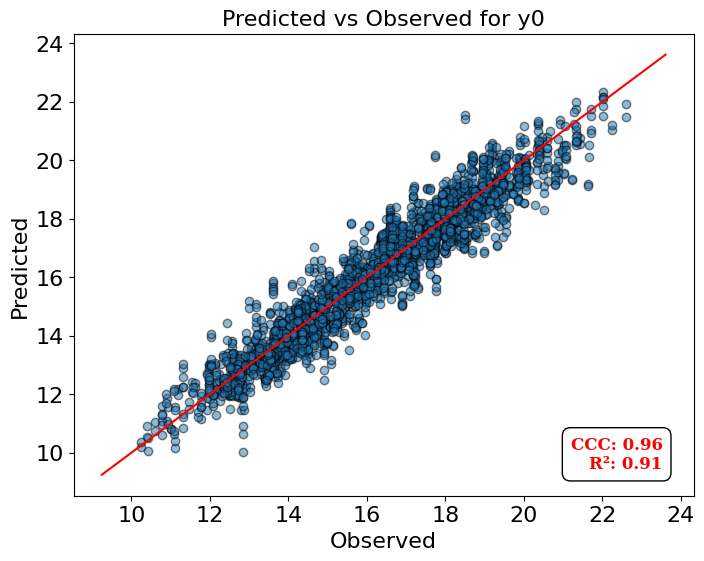

In [22]:
print(min(val_losses))
utils.test(model, final_path, test_loader,config)

In [23]:
total = 0
print("Nombre de paramètres par couche :")
for nom, param in model.named_parameters():
    if param.requires_grad:
        nb_params = param.numel()
        print(f"{nom}: {nb_params}")
        total += nb_params

print(f"\nNombre total de paramètres : {total}")

Nombre de paramètres par couche :
conv1d.weight: 30
conv1d.bias: 6
fc1.weight: 26368
fc1.bias: 128
fc2.weight: 8192
fc2.bias: 64
fc3.weight: 2048
fc3.bias: 32
norm.weight: 1236
norm.bias: 1236
output_layer.weight: 32
output_layer.bias: 1

Nombre total de paramètres : 39373


In [24]:

Xcal_reshape = Xcal_concat.reshape((Xcal_concat.shape[0], -1))
Xval_reshape = Xval_concat.reshape((Xval_concat.shape[0], -1))
Xtest_reshape = Xtest_concat.reshape((Xtest_concat.shape[0], -1))
mean_reshape = Xcal_reshape.mean(axis=0)
std_reshape = Xcal_reshape.std(axis=0)
print("mean_reshape = ", mean_reshape.shape)
print("std_reshape = ", std_reshape.shape)

mean_reshape =  (1236,)
std_reshape =  (1236,)


In [25]:
from src.net import Darionet



cal = data_utils.TensorDataset(torch.Tensor(Xcal_reshape), torch.Tensor(Ycal))
cal_loader = data_utils.DataLoader(cal, batch_size=config.batch_size, shuffle=True)

val = data_utils.TensorDataset(torch.Tensor(Xval_reshape), torch.Tensor(Yval))
val_loader = data_utils.DataLoader(val, batch_size=config.batch_size, shuffle=False)

test_dt = data_utils.TensorDataset(torch.Tensor(Xtest_reshape), torch.Tensor(Ytest))
test_loader = data_utils.DataLoader(test_dt, batch_size=config.batch_size, shuffle=False)


In [26]:
model_name = 'DarioNet'
config.model_name = model_name
model = Darionet(mean = mean_reshape, std = std_reshape ,filter_size = 45, reg_beta = 0.015, input_dims = Xcal_reshape.shape[-1],out_dims=1)
config.num_epochs = 1000


Darionet(
  (conv1): Conv1d(1, 1, kernel_size=(45,), stride=(1,), padding=same)
  (fc1): Linear(in_features=1236, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=16, bias=True)
  (output_layer): Linear(in_features=16, out_features=1, bias=True)
)
Saving best model to /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/DOE_TMA_Mango_Dario_split_replicate_ok_N13_best.pth
Epoch 1/1000 | Train Loss: 87.3514 | Val Loss: 15.8655 | Val Mean Metrics: -1.6889
Model saved at epoch 0 to /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/DOE_TMA_Mango_Dario_split_replicate_ok_N13_best.pth
Epoch 2/1000 | Train Loss: 12.7918 | Val Loss: 9.5368 | Val Mean Metrics: -0.6163
Model saved at epoch 1 to /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/DOE_TMA_Mango_Dario_split_r

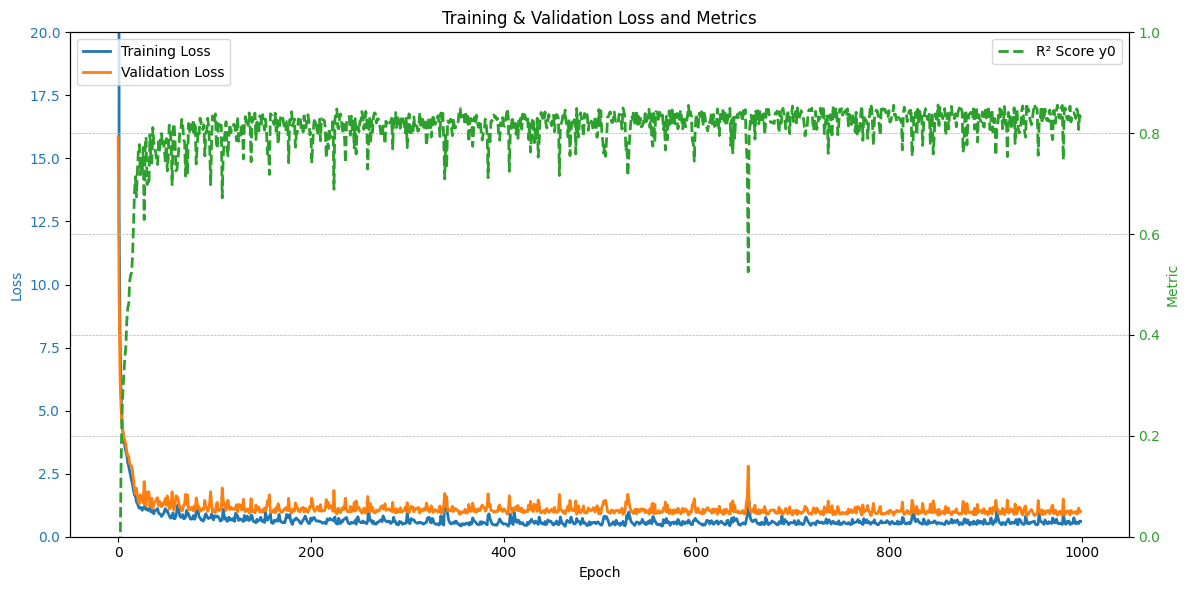

Training completed for DarioNet. Final path: /home/localadmin/Documents/Progetti/Post_DOC/Lavori/Preprocessing_project/Deep-Chemometrics/models/DOE_TMA_Mango_Dario_split_replicate_ok_N13_best.pth


In [27]:
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=0.015)
criterion = nn.MSELoss(reduction='none')
print(model)

trainer = Trainer(model=model, optimizer=optimizer, criterion=criterion, train_loader=cal_loader, val_loader=val_loader, config=config,verbose=True)

train_losses, val_losses,val_r2_scores, final_path = trainer.train()
print(f"Training completed for {model_name}. Final path: {final_path}")



CCC: 0.9309168955702528, R2: 0.8696466684341431, RMSEP: 0.8756282925605774
Shape of Y: (2331,), Shape of y_pred: (2331,)


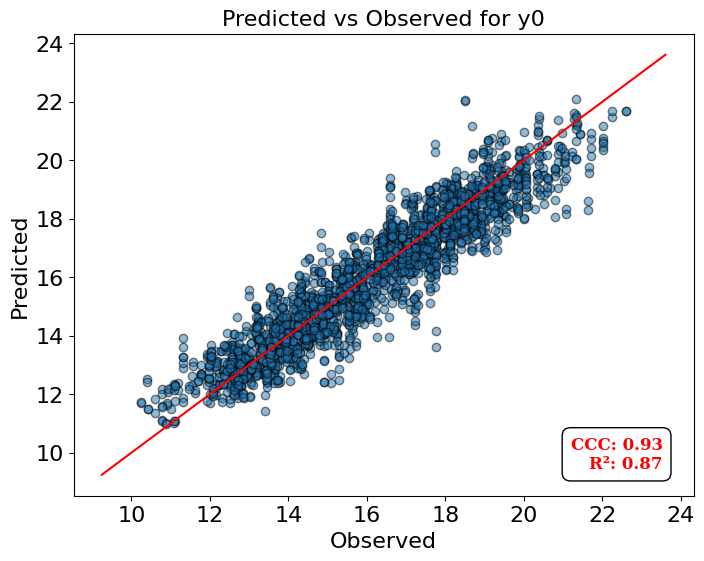

In [28]:
utils.test(model, final_path, test_loader,config)

In [29]:
total = 0
print("Nombre de paramètres par couche :")
for nom, param in model.named_parameters():
    if param.requires_grad:
        nb_params = param.numel()
        print(f"{nom}: {nb_params}")
        total += nb_params

print(f"\nNombre total de paramètres : {total}")

Nombre de paramètres par couche :
conv1.weight: 45
conv1.bias: 1
fc1.weight: 158208
fc1.bias: 128
fc2.weight: 8192
fc2.bias: 64
fc3.weight: 1024
fc3.bias: 16
output_layer.weight: 16
output_layer.bias: 1

Nombre total de paramètres : 167695
